In [ ]:
library(data.table)
library(dplyr)
library(ggplot2)
library(qqman)

## Simulating GWAS Datasets with BioGWAS and generating summary stats

[Link to bioGWAS paper here](https://www.mdpi.com/2079-7737/13/1/10)

What the BioGWAS framework does:
- simulates genotype data matrix (N*M) under some frequency of allele assumptions
- defines a subset of causal gene variants
- generates phenotypes under specific genetic architecture
- performs SNP-wise association



The model to simulate data is:
$$ y = X \beta + \epsilon $$
- X: Genotype matrix
- $\beta$: SNP effects (sparse vector, mostly zero since most SNPs dont effect)
- $\epsilon$: noise term for simulation

Assumptions:
- SNPs all have only two alleles
- hence, genotypes are only encoded as 0, 1, or 2 depending on effected allele count
- some independence assumption amongst SNPs -> **ASSUMING NO LINKAGE DISEQUILIBRIUM**

#### Specification of params

In [1]:
set.seed(37)

n_individuals <- 2000      # Number of samples
n_snps <- 10000            # Number of SNPs
n_causal <- 20             # Number of causal variants
heritability <- 0.4        # Proportion of variance explained genetically


### Minor Allele Frequencies (MAF)

- 2 alleles in every SNP
- one with less frequency in population (minor allele), other major 
- MAF: the fraction of chromosomes in the population that carry the minor allele

In [ ]:
maf <- runif(n_snps, min = 0.05, max = 0.5)

### Genotype Matrix
(follows something called Hardy–Weinberg equilibrium:)
$$ G \sim \text{Binomial}(2, \text{MAF})$$

In the $N \cdot M$ matrix:
- rows are individuals 
- columns are SNPs


In [8]:
genotypes <- sapply(maf, function(p) {
  rbinom(n_individuals, size = 2, prob = p)
})

genotypes <- as.matrix(genotypes)


bioGWAS paper mentions explcitly defining the causal SNP variants while simulating

Note: the assumption here is "many SNPs exist but only few have real effects on phenotypes"

In [ ]:
# here beta for something is not equal to zero only if it belongs to causal_snps
causal_snps <- sample(1:n_snps, n_causal)

effect sizes ($\beta$) are drawn from a normal distribution

In [10]:
beta <- rep(0, n_snps)
beta[causal_snps] <- rnorm(n_causal, mean = 0, sd = 0.2)


We had: 

$$ y = X \beta + \epsilon $$

- $X \beta$ is the genetic component
- $\epsilon$ is the environmental noise

Effectively we sum over it:

$$ y = \sum_{j} G_j \beta_j + \epsilon $$


In [ ]:
genetic_score <- genotypes %*% beta

var_g <- var(genetic_score)
var_e <- var_g * (1 - heritability) / heritability

environmental_noise <- rnorm(n_individuals, mean = 0, sd = sqrt(var_e))

final phenotype ($y$)

In [ ]:
phenotype <- as.numeric(genetic_score + environmental_noise)

### SNP-wise association testing

idea is to fit a regression model individually to each SNP:
$$ y = \beta_{0} + \beta_{1} \cdot \text{SNP} + \epsilon$$

this creates a final results dataframe from which we can get summary stats

In [ ]:
# association loop for applying everything to each SNP

gwas_results <- lapply(1:n_snps, function(j) {
  model <- lm(phenotype ~ genotypes[, j])
  summary_model <- summary(model)
  
  data.frame(
    beta = summary_model$coefficients[2, 1],
    se = summary_model$coefficients[2, 2],
    p_value = summary_model$coefficients[2, 4]
  )
})

gwas_results <- bind_rows(gwas_results)


(just a step to add metadata to mirror the structure of real GWAS summary stats)

In [15]:
gwas_results <- gwas_results %>%
  mutate(
    SNP = paste0("rs", 1:n_snps),
    CHR = sample(1:22, n_snps, replace = TRUE),
    BP = sample(1:1e6, n_snps, replace = TRUE)
  )


### Manhattan Plot

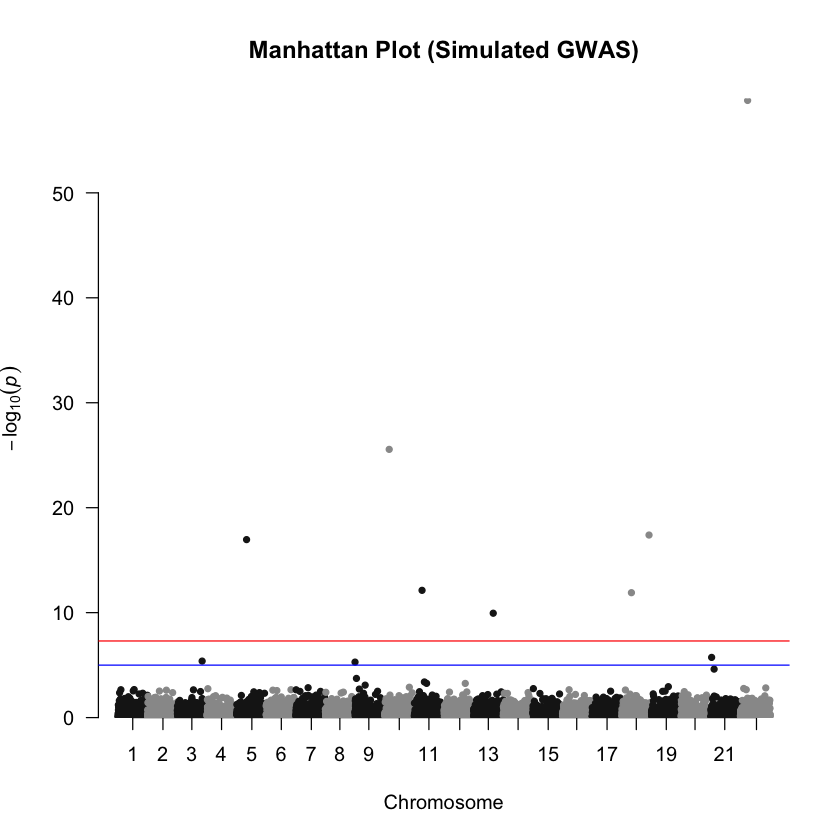

In [16]:
manhattan(
  gwas_results,
  chr = "CHR",
  bp = "BP",
  snp = "SNP",
  p = "p_value",
  genomewideline = -log10(5e-8),
  suggestiveline = -log10(1e-5),
  main = "Manhattan Plot (Simulated GWAS)"
)


### Q-Q Plot

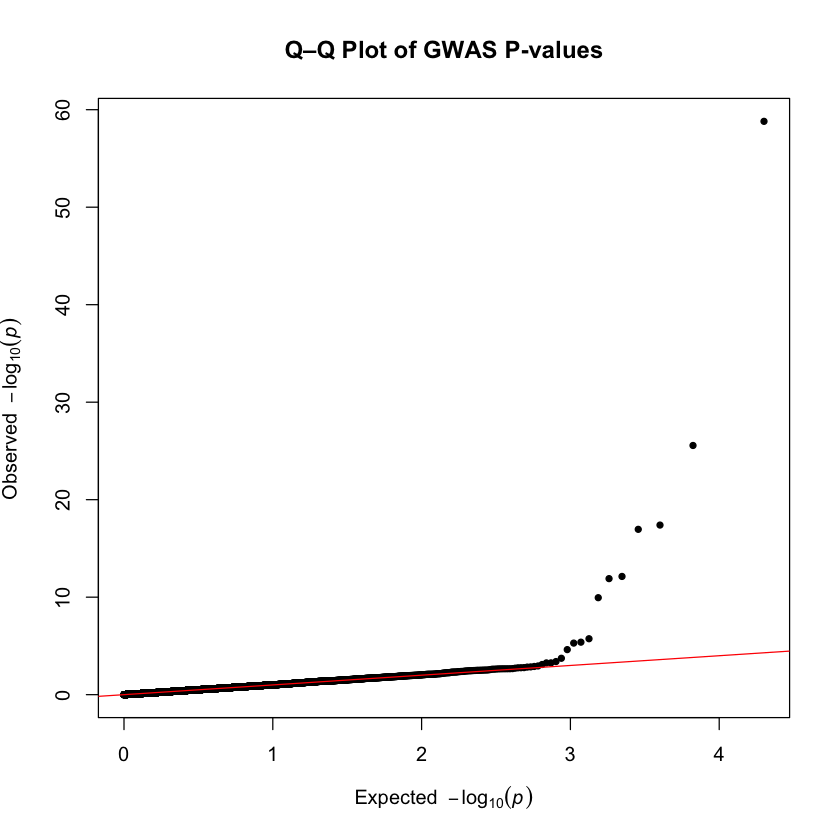

In [17]:
qq(gwas_results$p_value, main = "Q–Q Plot of GWAS P-values")


### Volcano Plot

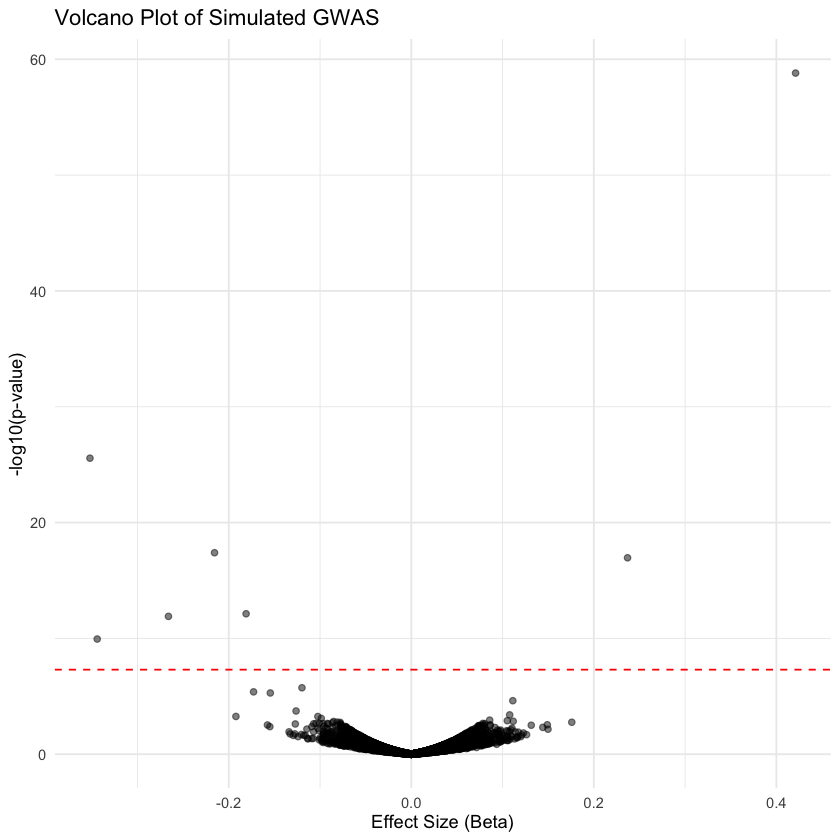

In [18]:
gwas_results %>%
  mutate(logP = -log10(p_value)) %>%
  ggplot(aes(x = beta, y = logP)) +
  geom_point(alpha = 0.5) +
  geom_hline(yintercept = -log10(5e-8), linetype = "dashed", color = "red") +
  theme_minimal() +
  labs(
    title = "Volcano Plot of Simulated GWAS",
    x = "Effect Size (Beta)",
    y = "-log10(p-value)"
  )
